Mean Squared Error:0.2554
R² Score:0.8051


/tmp/ipykernel_3095/1583105361.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance',y='Feature',data=feature_importance_df,palette='viridis')


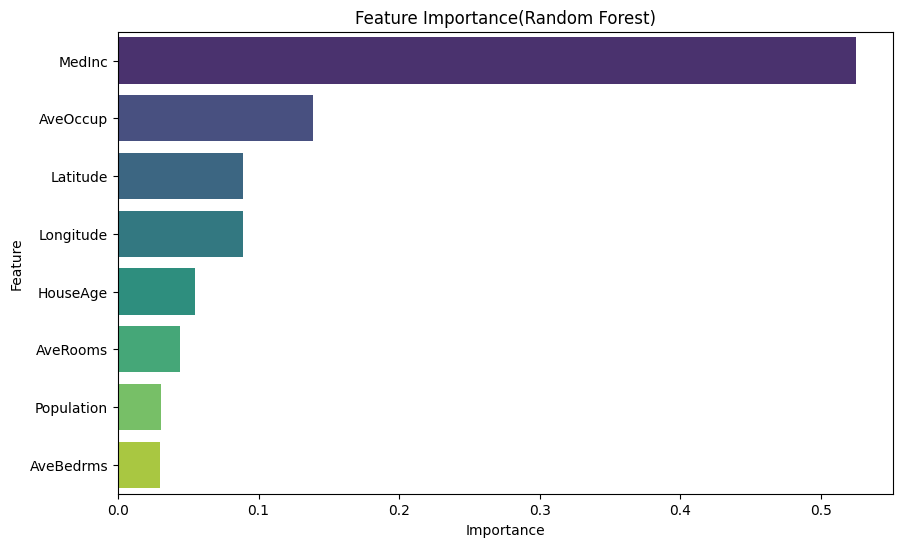

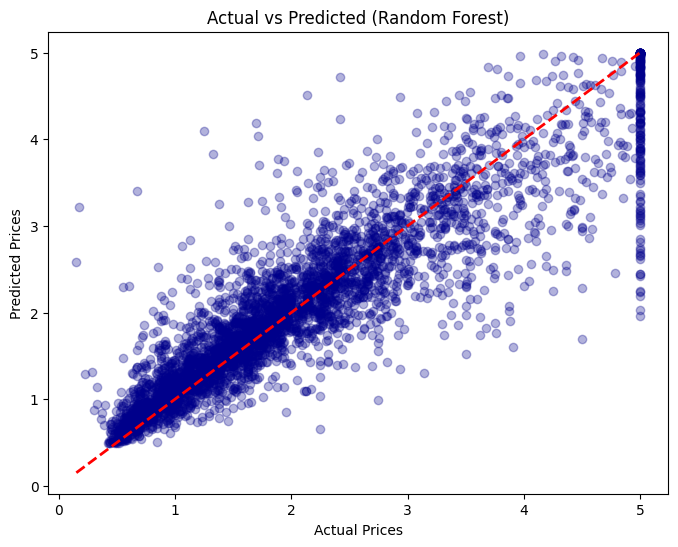

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
housing=fetch_california_housing(as_frame=True)
df=housing.frame
X=df.drop('MedHouseVal', axis=1)
y=df['MedHouseVal']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
rf_model=RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)
rf_model.fit(X_train,y_train)
y_pred=rf_model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test, y_pred)
print(f"Mean Squared Error:{mse:.4f}")
print(f"R² Score:{r2:.4f}")
importances=rf_model.feature_importances_
feature_names=X.columns
feature_importance_df=pd.DataFrame({'Feature':feature_names,'Importance':importances}).sort_values(by='Importance',ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance',y='Feature',data=feature_importance_df,palette='viridis')
plt.title('Feature Importance(Random Forest)')
plt.show()
plt.figure(figsize=(8, 6))
plt.scatter(y_test,y_pred,alpha=0.3,color='darkblue')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--',lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted (Random Forest)')
plt.show()